In [1]:
!pip install gdown

In [2]:
link_do_arquivo = 'https://drive.google.com/file/d/1qe6trcEAHHvcfT5lT0JdbDQ4nCVhKgcE/view?usp=sharing'
file_id = link_do_arquivo.split('/d/')[1].split('/')[0]
import gdown
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'converted_data.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1qe6trcEAHHvcfT5lT0JdbDQ4nCVhKgcE
To: /content/converted_data.csv
100%|██████████| 2.20k/2.20k [00:00<00:00, 873kB/s]


'converted_data.csv'

# # Importar bibliotecas necessárias

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error

# # Carregar o dataset





In [4]:
url = '/content/converted_data.csv'
data = pd.read_csv(url, header=0, sep=';')

# The CSV is already parsed into 'Date' and 'Production' columns.
# Rename 'Date' to 'Ano'
data = data.rename(columns={'Date': 'Ano'})

# Ensure 'Production' column is of float type
data['Production'] = data['Production'].astype(float)

# Extract only the 'Production' values for the time series analysis
data = data['Production'].values

print(data)

[589. 561. 640. 656. 727. 697. 640. 599. 568. 577. 553. 582. 600. 566.
 653. 673. 742. 716. 660. 617. 583. 587. 565. 598. 628. 618. 688. 705.
 770. 736. 678. 639. 604. 611. 594. 634. 658. 622. 709. 722. 782. 756.
 702. 653. 615. 621. 602. 635. 677. 635. 736. 755. 811. 798. 735. 697.
 661. 667. 645. 688. 713. 667. 762. 784. 837. 817. 767. 722. 681. 687.
 660. 698. 717. 696. 775. 796. 858. 826. 783. 740. 701. 706. 677. 711.
 734. 690. 785. 805. 871. 845. 801. 764. 725. 723. 690. 734. 750. 707.
 807. 824. 886. 859. 819. 783. 740. 747. 711. 751. 804. 756. 860. 878.
 942. 913. 869. 834. 790. 800. 763. 800. 826. 799. 890. 900. 961. 935.
 894. 855. 809. 810. 766. 805. 821. 773. 883. 898. 957. 924. 881. 837.
 784. 791. 760. 802. 828. 778. 889. 902. 969. 947. 908. 867. 815. 812.
 773. 813. 834. 782. 892. 903. 966. 937. 896. 858. 817. 827. 797. 843.]


# # Normalização dos dados


In [5]:
print(f"Data min before scaling: {data.min()}")
print(f"Data max before scaling: {data.max()}")
print(f"Does data contain NaNs before scaling?: {np.isnan(data).any()}")

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data.reshape(-1, 1))

print(f"First 5 scaled data points: {data_scaled[:5].flatten()}")
print(f"Last 5 scaled data points: {data_scaled[-5:].flatten()}")
print(f"Does scaled data contain NaNs?: {np.isnan(data_scaled).any()}")

Data min before scaling: 553.0
Data max before scaling: 969.0
Does data contain NaNs before scaling?: False
First 5 scaled data points: [0.08653846 0.01923077 0.20913462 0.24759615 0.41826923]
Last 5 scaled data points: [0.73317308 0.63461538 0.65865385 0.58653846 0.69711538]
Does scaled data contain NaNs?: False


# Função para criar as janelas de tempo

In [6]:
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

## # Função para criar e treinar o modelo RNN

In [7]:
def train_rnn(time_step):
    X, y = create_dataset(data_scaled, time_step)
    X = X.reshape(X.shape[0], X.shape[1], 1)

    # Dividir os dados em treino e teste
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    # Criar o modelo RNN
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(100, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    # Compilar o modelo
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Treinar o modelo
    model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

    # Fazer previsões
    predictions = model.predict(X_test)
    print(f"Does predictions from model.predict contain NaNs for time_step {time_step}?: {np.isnan(predictions).any()}")
    predictions = scaler.inverse_transform(predictions)

    # Calcular o erro
    y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
    mse = mean_squared_error(y_test_inverse, predictions)

    return mse, predictions, y_test_inverse

# Avaliar o modelo com diferentes janelas de tempo


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 438ms/step
Does predictions from model.predict contain NaNs for time_step 2?: False


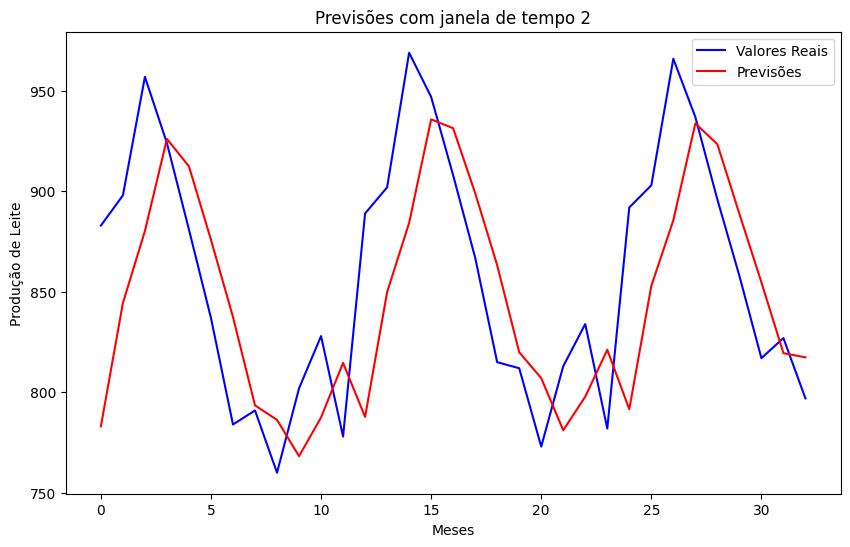

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step
Does predictions from model.predict contain NaNs for time_step 4?: False


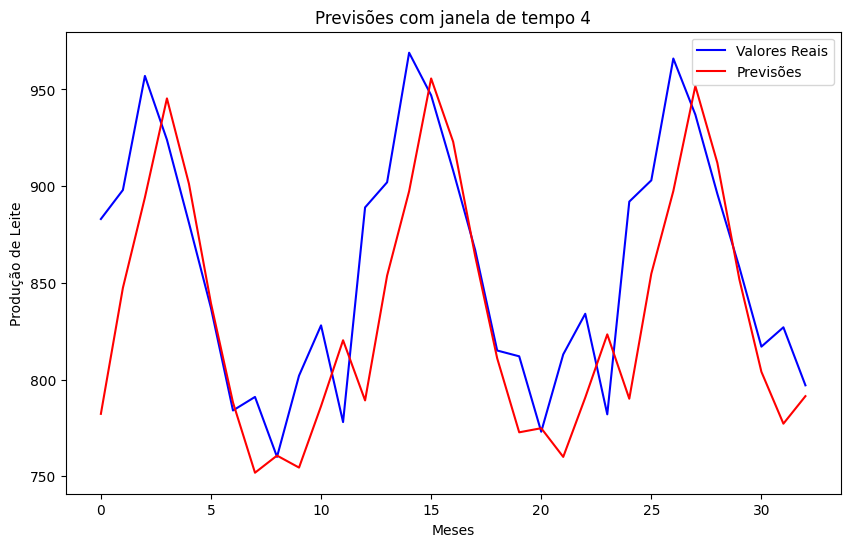

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 299ms/step
Does predictions from model.predict contain NaNs for time_step 6?: False


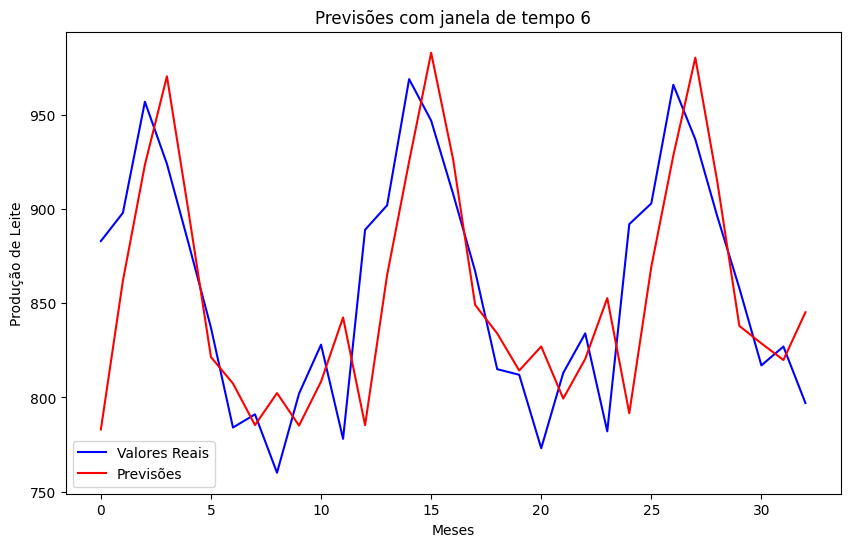

In [8]:
time_steps = [2, 4, 6]
results = {}

for step in time_steps:
    mse, predictions, y_test_inverse = train_rnn(step)
    results[step] = mse
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inverse, label='Valores Reais', color='blue')
    plt.plot(predictions, label='Previsões', color='red')
    plt.title(f'Previsões com janela de tempo {step}')
    plt.xlabel('Meses')
    plt.ylabel('Produção de Leite')
    plt.legend()
    plt.show()

# # Exibir os resultados dos erros

In [9]:
print("Mean Squared Errors para diferentes janelas de tempo:")
for step, mse in results.items():
    print(f"Janela de Tempo {step}: MSE = {mse}")

Mean Squared Errors para diferentes janelas de tempo:
Janela de Tempo 2: MSE = 2449.3064344064737
Janela de Tempo 4: MSE = 2157.2845674708014
Janela de Tempo 6: MSE = 1961.1476089097541


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
Prediction for 1975: [[833.8226]]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 307ms/step
Does predictions from model.predict contain NaNs for time_step 6?: False


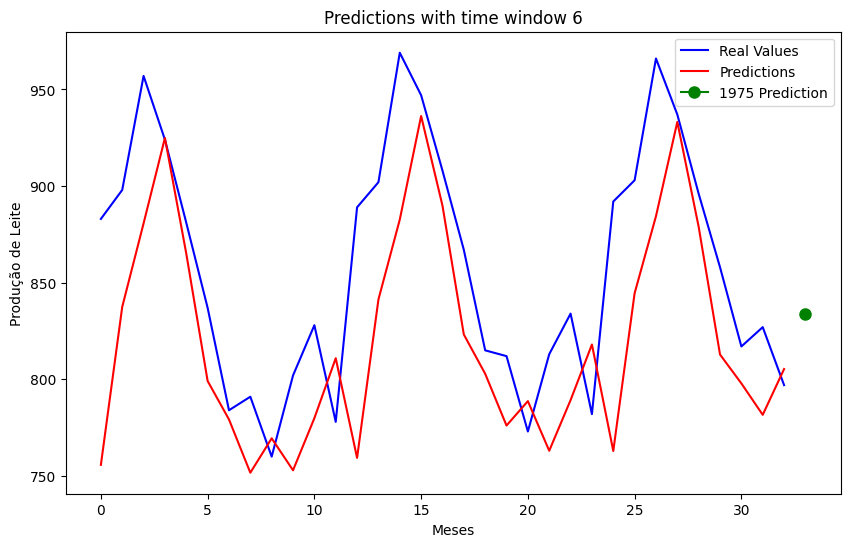

In [12]:
import numpy as np

# ... (Your existing code)

# Predict for 1975
def predict_1975(time_step):
    X, y = create_dataset(data_scaled, time_step)
    X = X.reshape(X.shape[0], X.shape[1], 1)

    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(100, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

    # Prepare input for prediction
    last_data_points = data_scaled[-time_step:]
    input_data = last_data_points.reshape(1, time_step, 1)

    # Predict
    prediction_1975 = model.predict(input_data)
    prediction_1975 = scaler.inverse_transform(prediction_1975)

    return prediction_1975

# Example usage (choose a time step)
time_step = 6  # Example
prediction_1975 = predict_1975(time_step)
print(f"Prediction for 1975: {prediction_1975}")


# Plotting (adjust as needed)
mse, predictions, y_test_inverse = train_rnn(time_step)
plt.figure(figsize=(10, 6))
plt.plot(y_test_inverse, label='Real Values', color='blue')
plt.plot(predictions, label='Predictions', color='red')

# Add the 1975 prediction as a single point at the end of the test series
# The x-coordinate should be the index after the last test point
plt.plot([len(y_test_inverse)], prediction_1975[0], marker='o', markersize=8, color='green', label='1975 Prediction')
# The 'years' variable was incorrectly used for plotting and xticks, removing for now
# plt.xticks(np.concatenate((years, [1975]))) # Set x-axis ticks


plt.title(f'Predictions with time window {time_step}')
plt.xlabel('Meses') # Keep xlabel as 'Meses' since data is likely monthly
plt.ylabel('Produção de Leite')
plt.legend()
plt.show()